# Stap 3 — Een model dat ligduur voorspelt

**Project:** APEX hackathon, St. Aurora Medical Center, afdeling Interne Geneeskunde 4C  
**Notebook:** 02_stap3_model  
**Auteur:** Sesmu  
**Datum:** september 2026  
**Vervolg op:** 01_stap1_leren_van_verleden

## Waar we vandaan komen

In notebook 01 hebben we vastgesteld dat de nationale benchmark op afdeling 4C
gemiddeld 3,9 dag naast de werkelijke ligduur zit, en dat die fout bijna volledig
systematisch is: patiënten liggen structureel langer dan de benchmark zegt. Een
correctie per diagnosecategorie (acht getallen, op train bepaald) brengt de fout
op de testset terug tot 2,44 dag. Daarmee is de opdracht (1 dag of 20% beter)
al gehaald zonder model.

Wat overblijft is spreiding: patiënten met dezelfde diagnose die toch verschillend
lang liggen. Fase 1 liet zien welke opnamekenmerken daarmee samenhangen: leeftijd
(vanaf 65 oplopend), aantal nevendiagnoses (sterkste losse voorspeller),
opnametype (spoed ligt langer dan gepland) en acute presentatie bij opname.
De benchmark negeert al deze kenmerken.

## Wat dit notebook doet

...uit de kenmerken die bij opname bekend zijn: de diagnose (als categorie en als benchmarkgetal), leeftijd, opnametype, nevendiagnoses, acute presentatie en vitale waarden.

We bouwen een model dat de ligduur per patiënt schat uit de kenmerken die bij
opname bekend zijn, en meten of dat model op de testset onder de 2,44 dag van
de gecorrigeerde benchmark komt. Lager is beter: de MAE is de gemiddelde fout
in dagen.



We proberen drie modellen, van simpel naar slim: lineaire regressie, random
forest en gradient boosting. Als het simpele model bijna even goed is als het
slimme, kiezen we het simpele, omdat dat aan de afdeling uit te leggen is.

## De lat

Alle aanpakken worden beoordeeld op dezelfde 1365 testpatiënten (20%,
`random_state=42`, identiek aan notebook 01):

| aanpak | MAE test (dagen) |
|---|---|
| benchmark origineel | 3,88 |
| iedereen de mediaan | 3,73 |
| benchmark + correctie per categorie | 2,44 |
| model (dit notebook) | moet hieronder komen |

## Spelregels

- Alleen kenmerken die bij opname bekend zijn. Uitgesloten: `discharge_date`,
  `discharge_notes`, `discharge_reason`, `dis_complicated`, `dis_to_facility`.
- Alles wat het model leert (invulwaarden, gewichten, splitsingen) leert het op
  train. De testset wordt één keer gebruikt, aan het eind, voor de eindscore.
- Instellingen vergelijken gebeurt met kruisvalidatie binnen train, nooit op test.

## Stappen

## Stappen

1. Data inlezen en splitsen, identiek aan notebook 01
2. Kenmerken (X) en uitkomst (y) kiezen; `year` en weekdag van opname erbij
3. Voorbewerken: lege waarden invullen, categorieën omzetten
4. Kenmerken onderling bekijken: welke vertellen hetzelfde (collineariteit)
5. Drie modellen trainen: lineaire regressie (uitgedunde X), random forest en
   gradient boosting (volledige X)
6. Beoordelen op test en vergelijken met de lat
7. Welke kenmerken deden het werk
8. Extra controles: fout per categorie, tijdsplitsing

## PS — twee vragen ten aanzien van variabele keuze en colineariteit

**"Hebben we alle variabelen bekeken?"**
Bijna. Fase 1 dekte diagnose, leeftijd, opnametype, nevendiagnoses, acute
presentatie, vitalen, BMI, specialisme en ervaring. Nog niet bekeken: `year`
(is de ligduur tussen 2012 en 2024 veranderd? belangrijk, want de huidige
patiënten zijn uit 2025) en weekdag van opname (vrijdagopname kan langer duren
door het weekend). Die twee nemen we mee. `insurance_provider` en
`room_number`/`bed_number` laten we bewust weg: geen klinische betekenis en
niet uit te leggen aan de afdeling.

**"Moeten we niet naar collineariteit kijken?"**
Ja, maar het hangt van het model af. Collineariteit is: twee kenmerken die
grotendeels hetzelfde vertellen. Wij hebben er een paar: `adm_type` E en
`adm_acute`; `n_secondary` en de acht `sec_*`; benchmark en
`diagnosis_category`; systolische en diastolische bloeddruk.

- *Lineaire regressie:* hier is het een echt probleem. De voorspelling blijft
  goed, maar de gewichten worden onbetrouwbaar, omdat het model het effect
  willekeurig over de twee overlappende kenmerken verdeelt. Het lineaire model
  krijgt daarom een uitgedunde X: van elk overlappend paar één kenmerk.
- *Random forest en gradient boosting:* hier maakt het voor de voorspelling
  weinig uit; een boom kiest per splitsing gewoon één van de twee. Alleen de
  feature importance wordt over de twee verdeeld, dus die lezen we per groep
  (bijv. "nevendiagnoses" = `n_secondary` + alle `sec_*` samen).

Stap 4 maakt de overlap zichtbaar met een correlatiematrix tussen de kenmerken
onderling, zodat de keuze voor de uitgedunde X gedocumenteerd is.

## Stap 3.0 — Inlezen en splitsen, identiek aan notebook 01

We herhalen hier de inlees-, datum-, koppel- en splitsstappen uit notebook 01,
zodat `train` en `test` exact dezelfde patiënten bevatten. Dezelfde bestanden,
dezelfde volgorde, dezelfde `random_state=42`. Aan het eind controleren we dat
met een vergelijking van de aantallen en gemiddelden uit notebook 01.

In [2]:
# ===== NB02 Cel 1 | Stap 3.0 | Pakketten en inlezen =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

hist  = pd.read_csv("/Users/SesmuArbous/Downloads/Analytical Apex/Output/patient_history_prepared.csv")
curr  = pd.read_csv("../Data/current_patients.csv")
diag  = pd.read_csv("../Data/diagnosis_lookup.csv")
staff = pd.read_csv("../Data/staff_lookup.csv")

print("historie:", hist.shape, " huidig:", curr.shape)

historie: (6825, 37)  huidig: (32, 19)


In [10]:
# ===== NB02 Cel 2 | Stap 3.0 | Datums, koppelen, benchmarkfout, eerdere opname =====
hist["admission_date"] = pd.to_datetime(hist["admission_date"])
hist["discharge_date"] = pd.to_datetime(hist["discharge_date"])
curr["admission_date"] = pd.to_datetime(curr["admission_date"], format="mixed")

df = hist.merge(staff, left_on="attending_physician_id", right_on="physician_id", how="left")
df["fout_benchmark"] = df["actual_los"] - df["typical_los_benchmark"]

# Eerdere opname: had deze patiënt al een eerdere opname in de historie?
# Bij binnenkomst bekend, dus toegestaan. Eerste opname = 0, tweede = 1.
df["eerdere_opname"] = (df.groupby("patient_id")["admission_date"].rank(method="first") > 1).astype(int)

print("df:", df.shape, " zonder arts:", df["specialty"].isna().sum(),
      " zonder benchmark:", df["typical_los_benchmark"].isna().sum())

df: (6825, 43)  zonder arts: 0  zonder benchmark: 0


In [11]:
# ===== NB02 Cel 3 | Stap 3.0 | Splitsen op patiënt-id =====
# 6825 rijen, 6500 unieke patiënten: 325 patiënten hebben twee opnames.
# We loten 20% van de UNIEKE patiënten voor test; al hun opnames gaan mee.
rng = np.random.default_rng(42)
alle_ids = df["patient_id"].unique()
test_ids = set(rng.choice(alle_ids, size=int(0.2 * len(alle_ids)), replace=False))

test  = df[df["patient_id"].isin(test_ids)].copy()
train = df[~df["patient_id"].isin(test_ids)].copy()

herhaal = df["patient_id"].value_counts()
herhaal = herhaal[herhaal > 1].index
print("train:", train.shape, " test:", test.shape)
print("patiënten in beide sets:", len(set(train["patient_id"]) & set(test["patient_id"])), "(moet 0 zijn)")
print("herhaalopnames in train:", train["patient_id"].isin(herhaal).sum(),
      " in test:", test["patient_id"].isin(herhaal).sum())
print("gemiddelde ligduur train:", round(train["actual_los"].mean(), 2),
      " test:", round(test["actual_los"].mean(), 2))

train: (5462, 43)  test: (1363, 43)
patiënten in beide sets: 0 (moet 0 zijn)
herhaalopnames in train: 524  in test: 126
gemiddelde ligduur train: 8.83  test: 8.88


In [12]:
# ===== NB02 Cel 4 | Stap 3.0 | De lat: referentiewaarden op deze testset =====
correctie = train.groupby("diagnosis_category")["fout_benchmark"].mean()
test["benchmark_gecorrigeerd"] = test["typical_los_benchmark"] + test["diagnosis_category"].map(correctie)

resultaten = {}
resultaten["benchmark origineel"]   = (test["actual_los"] - test["typical_los_benchmark"]).abs().mean()
resultaten["iedereen de mediaan"]   = (test["actual_los"] - train["actual_los"].median()).abs().mean()
resultaten["benchmark + correctie"] = (test["actual_los"] - test["benchmark_gecorrigeerd"]).abs().mean()

for naam, mae in resultaten.items():
    print(f"{naam:25s} MAE {mae:.2f} dagen")

benchmark origineel       MAE 3.70 dagen
iedereen de mediaan       MAE 3.65 dagen
benchmark + correctie     MAE 2.39 dagen


## Stap 3.1 — Kenmerken (X) en uitkomst (y)

**Doel:** vastleggen welke kolommen het model mag zien.

**Waarom:** alles wat pas bij ontslag bekend is blijft erbuiten. De lijst komt uit
fase 1, aangevuld met `year`, weekdag van opname en `eerdere_opname`. Kolommen
zonder klinische betekenis (kamer, bed, verzekeraar, naam, id) laten we weg.

In [13]:
# ===== NB02 Cel 5 | Stap 3.1 | Afgeleide kenmerken uit de opnamedatum =====
for d in (train, test):
    d["weekdag"] = d["admission_date"].dt.dayofweek        # 0 = maandag ... 6 = zondag
    d["weekend_opname"] = (d["weekdag"] >= 5).astype(int)
    d["bmi_ontbreekt"] = d["bmi"].isna().astype(int)

print("=== per weekdag (train) ===")
print(train.groupby("weekdag")["actual_los"].agg(aantal="size", ligduur="mean").round(2))
print("\n=== per jaar (train) ===")
print(train.groupby("year")["actual_los"].agg(aantal="size", ligduur="mean").round(2))

=== per weekdag (train) ===
         aantal  ligduur
weekdag                 
0           794     8.61
1           756     9.01
2           773     8.61
3           782     8.98
4           735     8.80
5           806     8.85
6           816     8.91

=== per jaar (train) ===
      aantal  ligduur
year                 
2012     407     8.69
2013     454     8.60
2014     393     8.98
2015     438     8.61
2016     399     8.75
2017     435     8.81
2018     441     8.68
2019     422     9.33
2020     381     8.98
2021     418     8.36
2022     434     9.04
2023     439     8.70
2024     401     9.28


In [14]:
# ===== NB02 Cel 6 | Stap 3.1 | X en y definiëren =====
numeriek = ["age", "typical_los_benchmark", "n_secondary", "adm_acute", "eerdere_opname",
            "sec_cardiovascular", "sec_respiratory", "sec_infectious", "sec_renal",
            "sec_metabolic", "sec_neurological", "sec_gastrointestinal", "sec_other",
            "bmi", "bmi_ontbreekt", "systolic_bp", "diastolic_bp", "heart_rate", "temperature",
            "years_experience", "year", "weekdag", "weekend_opname"]

categorisch = ["adm_type", "sex", "diagnosis_category", "specialty"]

uitgesloten = ["discharge_date", "discharge_notes", "discharge_reason",
               "dis_complicated", "dis_to_facility", "actual_los",
               "patient_id", "name", "physician_id", "attending_physician_id",
               "room_number", "bed_number", "insurance_provider",
               "admission_notes", "secondary_diagnosis_codes", "primary_diagnosis_code",
               "diagnosis_description", "admission_date", "fout_benchmark"]

kenmerken = numeriek + categorisch
X_train, y_train = train[kenmerken], train["actual_los"]
X_test,  y_test  = test[kenmerken],  test["actual_los"]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("aantal kenmerken:", len(kenmerken), "=", len(numeriek), "numeriek +", len(categorisch), "categorisch")
assert not set(kenmerken) & set(uitgesloten), "verboden kolom in X!"
print("Geen verboden kolommen in X.")

X_train: (5462, 27)  X_test: (1363, 27)
aantal kenmerken: 27 = 23 numeriek + 4 categorisch
Geen verboden kolommen in X.


Weekdag: geen effect. Ligduur 8,6 tot 9,0, zonder patroon; vrijdag (4) ligt niet langer, weekend niet anders. Ook opvallend: evenveel opnames op zaterdag en zondag als op weekdagen. Dat past niet bij een echte afdeling (geplande opnames komen zelden in het weekend), en het is een teken dat deze data gesimuleerd is. Voor het model: weekdag en weekend_opname mogen erin blijven, maar verwacht er niets van.
Jaar: geen trend. Tussen 8,4 en 9,3, schommelend, zonder daling of stijging over dertien jaar. Dat is goed nieuws: een model geleerd op 2012–2024 is gewoon toepasbaar op 2025, en de tijdsplitsing straks zal weinig verrassingen geven. Ook hier: jaar mag erin, doet waarschijnlijk niets.
Voor de markdown: Weekdag en jaar laten geen verband met ligduur zien. Geen trend over 2012–2024, dus het model is zonder correctie toepasbaar op 2025. De gelijke verdeling van opnames over weekdagen en weekend wijst op gesimuleerde data.


## Stap 3.2 — Voorbewerken

**Doel:** gaten vullen en categorieën omzetten naar getallen, op een manier die
alleen van train leert.

**Waarom een Pipeline:** voorbewerking en model zitten in één object. `.fit()` leert
alles op train (medianen, categorieën, modelparameters), `.predict()` past het toe
op test. Zo kan de testset niet per ongeluk meepraten, en gebruiken alle modellen
straks exact dezelfde voorbewerking.

In [15]:
# ===== NB02 Cel 7 | Stap 3.2 | Voorbewerking definiëren =====
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Getallen: gaten vullen met de mediaan (geleerd op train).
numeriek_stappen = Pipeline([
    ("vul_gaten", SimpleImputer(strategy="median")),
])

# Categorieën: omzetten naar ja/nee-kolommen.
#   handle_unknown="ignore": een categorie die alleen in test voorkomt geeft geen fout, maar allemaal nullen.
categorisch_stappen = Pipeline([
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

# ColumnTransformer past per groep kolommen de juiste bewerking toe.
voorbewerking = ColumnTransformer([
    ("num", numeriek_stappen, numeriek),
    ("cat", categorisch_stappen, categorisch),
])

# Testen: leer op train, pas toe op train, en kijk wat eruit komt.
Xt = voorbewerking.fit_transform(X_train)
print("Na voorbewerking:", Xt.shape, "(27 kenmerken zijn", Xt.shape[1], "kolommen geworden)")
print("Gaten over:", np.isnan(Xt.toarray() if hasattr(Xt, "toarray") else Xt).sum(), "(moet 0 zijn)")

Na voorbewerking: (5462, 42) (27 kenmerken zijn 42 kolommen geworden)
Gaten over: 0 (moet 0 zijn)


In [16]:
# ===== NB02 Cel 8 | Stap 3.2 | Welke kolommen zijn het geworden? =====
# Handig voor later, als we feature importance willen lezen: de namen van alle kolommen na voorbewerking.
kolomnamen = voorbewerking.get_feature_names_out()
print(len(kolomnamen), "kolommen:")
for k in kolomnamen:
    print("  ", k)

42 kolommen:
   num__age
   num__typical_los_benchmark
   num__n_secondary
   num__adm_acute
   num__eerdere_opname
   num__sec_cardiovascular
   num__sec_respiratory
   num__sec_infectious
   num__sec_renal
   num__sec_metabolic
   num__sec_neurological
   num__sec_gastrointestinal
   num__sec_other
   num__bmi
   num__bmi_ontbreekt
   num__systolic_bp
   num__diastolic_bp
   num__heart_rate
   num__temperature
   num__years_experience
   num__year
   num__weekdag
   num__weekend_opname
   cat__adm_type_E
   cat__adm_type_P
   cat__adm_type_T
   cat__sex_F
   cat__sex_M
   cat__diagnosis_category_Cardiovascular
   cat__diagnosis_category_Gastrointestinal
   cat__diagnosis_category_Infectious
   cat__diagnosis_category_Metabolic
   cat__diagnosis_category_Neurological
   cat__diagnosis_category_Other
   cat__diagnosis_category_Renal
   cat__diagnosis_category_Respiratory
   cat__specialty_Cardiology
   cat__specialty_Gastroenterology
   cat__specialty_Infectious Disease
   cat__special

In [17]:
# ===== NB02 Cel 9 | Stap 3.3 | Sterk samenhangende paren =====
# Correlatiematrix tussen de numerieke kenmerken (op train, gaten gevuld met mediaan).
# We tonen alleen paren met |correlatie| > 0.2, gesorteerd.
X_num = X_train[numeriek].fillna(X_train[numeriek].median())
corr = X_num.corr().abs()

paren = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))   # bovenste driehoek: elk paar één keer
             .stack()
             .sort_values(ascending=False))
print("Paren met |r| > 0.2:")
print(paren[paren > 0.2].round(2))

Paren met |r| > 0.2:
weekdag      weekend_opname          0.80
n_secondary  sec_cardiovascular      0.42
             sec_infectious          0.37
             sec_metabolic           0.37
             sec_respiratory         0.37
             sec_gastrointestinal    0.34
             sec_renal               0.31
             sec_neurological        0.26
             sec_other               0.22
dtype: float64


In [18]:
# ===== NB02 Cel 10 | Stap 3.3 | Categorie vs opnametype vs acuut =====
# Twee overlappen die niet in een correlatiematrix zichtbaar zijn omdat ze categorisch zijn:
# - is een spoedopname (E) meestal ook acuut (adm_acute)?
# - hangt de benchmark één-op-één aan de categorie?
print("adm_acute per opnametype (aandeel acuut):")
print(train.groupby("adm_type")["adm_acute"].mean().round(2))
print("\nbenchmark per categorie (min, max, aantal verschillende waarden):")
print(train.groupby("diagnosis_category")["typical_los_benchmark"].agg(["min", "max", "nunique"]))

adm_acute per opnametype (aandeel acuut):
adm_type
E    0.51
P    0.48
T    0.48
Name: adm_acute, dtype: float64

benchmark per categorie (min, max, aantal verschillende waarden):
                    min   max  nunique
diagnosis_category                    
Cardiovascular      3.1   8.3        7
Gastrointestinal    2.6   7.4        5
Infectious          8.6  11.2        5
Metabolic           2.8   4.8        5
Neurological        2.9   7.8        3
Other               2.1   2.3        2
Renal               2.9   6.3        4
Respiratory         4.1   9.1        5


In cel 9 en 10 hebben we niets veranderd aan de data of het model. We hebben alleen gekeken of er kenmerken zijn die dubbelop zijn.
Cel 9 legde alle getalsmatige kenmerken naast elkaar en zocht paren die sterk samenhangen. Twee gevonden: het aantal nevendiagnoses met de acht losse soort-kolommen (logisch, het aantal is de som), en weekdag met weekend (logisch, het ene is uit het andere gemaakt). Verder niets. Zelfs boven- en onderdruk hangen niet samen, en dat is in echte patiënten onmogelijk; het is een aanwijzing dat de data gesimuleerd is.
Cel 10 deed hetzelfde voor twee overlappen die je niet in een correlatie kunt vangen omdat het categorieën zijn. Is een spoedopname meestal ook "acuut" volgens het notitiesjabloon? Nee: bij spoed, gepland en overplaatsing is ongeveer de helft acuut. De twee kenmerken zeggen dus iets verschillends en blijven allebei. Hangt de benchmark één-op-één aan de diagnosecategorie? Nee: binnen cardiovasculair zijn er zeven verschillende benchmarkwaarden. De benchmark is fijner dan de categorie, dus ook die blijven allebei.
Waarom dit uitmaakte. Voor het lineaire model is dubbelop een probleem: het verdeelt het effect willekeurig over de twee overlappende kenmerken en dan kun je de gewichten niet meer uitleggen. Daarom heeft cel 11 een uitgedunde lijst gemaakt voor het lineaire model: zonder de acht soort-kolommen en zonder weekend. Voor de twee boommodellen maakt het niet uit; die krijgen alles.
Kort samengevat, cel 5 t/m 11: we hebben bepaald wat het model mag zien (27 kenmerken, cel 6), gezorgd dat het allemaal getallen zonder gaten zijn (cel 7–8), gecontroleerd op dubbelop (cel 9–10), en een kortere lijst gemaakt voor het lineaire model (cel 11). Nu staat alles klaar om te trainen. Dat is cel 12–16.


De lijst voor het lineaire model staat in numeriek_lineair (cel 11). Dat zijn de 23 numerieke kenmerken uit cel 6 minus de negen die we eruit hebben gehaald:
Blijft (14 numeriek):
age, typical_los_benchmark, n_secondary, adm_acute, eerdere_opname, bmi, bmi_ontbreekt, systolic_bp, diastolic_bp, heart_rate, temperature, years_experience, year, weekdag
Plus de 4 categorische (ongewijzigd): adm_type, sex, diagnosis_category, specialty
Eruit (9): de acht sec_* (zitten al in n_secondary) en weekend_opname (zit al in weekdag)
De twee boommodellen krijgen de volledige 23 + 4.
Als je wilt zien wat cel 11 precies heeft gemaakt, draai:
python
print(numeriek_lineair)


## Stap 3.4 — Drie modellen trainen en beoordelen

Van simpel naar slim. Elk model zit in een pipeline met de voorbewerking, leert
op train en wordt één keer beoordeeld op test. Per model bewaren we de MAE en
het aandeel patiënten binnen ±1 dag.

- **Lineaire regressie:** elk kenmerk krijgt één gewicht. Uitlegbaar, ziet geen knikken.
  Krijgt de uitgedunde X.
- **Random forest:** honderden beslisbomen, gemiddelde als voorspelling. Ziet knikken
  en combinaties.
- **Gradient boosting:** bomen die elk van de fouten van de vorige leren. Meestal het
  nauwkeurigst op tabeldata.

In [21]:
# ===== NB02 Cel 11 | Stap 3.3 | Uitgedunde kenmerkenlijst voor het lineaire model =====
# Weg: de acht sec_* (overlappen met n_secondary) en weekend_opname (afgeleid van weekdag).
sec_kolommen = [k for k in numeriek if k.startswith("sec_")]
weg_lineair = sec_kolommen + ["weekend_opname"]
numeriek_lineair = [k for k in numeriek if k not in weg_lineair]

voorbewerking_lineair = ColumnTransformer([
    ("num", numeriek_stappen, numeriek_lineair),
    ("cat", categorisch_stappen, categorisch),
])
print("Lineair model krijgt", len(numeriek_lineair), "numerieke +", len(categorisch), "categorische kenmerken")
print("Weggelaten:", weg_lineair)

Lineair model krijgt 14 numerieke + 4 categorische kenmerken
Weggelaten: ['sec_cardiovascular', 'sec_respiratory', 'sec_infectious', 'sec_renal', 'sec_metabolic', 'sec_neurological', 'sec_gastrointestinal', 'sec_other', 'weekend_opname']


In [22]:
# ===== NB02 Cel 12 | Stap 3.4 | Hulpfunctie: model beoordelen op test =====
# Eén functie die elk model op dezelfde manier beoordeelt en het resultaat bewaart,
# zodat de vergelijking eerlijk is en de code niet drie keer herhaald wordt.
def beoordeel(naam, pipeline):
    pipeline.fit(X_train, y_train)               # leren op train (voorbewerking + model)
    voorspelling = pipeline.predict(X_test)      # toepassen op test
    fout = y_test - voorspelling
    resultaten[naam] = fout.abs().mean()
    binnen_1dag[naam] = (fout.abs() <= 1).mean()
    print(f"{naam:25s} MAE {fout.abs().mean():.2f} dagen   binnen ±1 dag: {(fout.abs() <= 1).mean()*100:.0f}%   bias {fout.mean():+.2f}")
    return pipeline

# Ook voor de drie referenties het aandeel binnen ±1 dag, zodat de tabel compleet is.
binnen_1dag = {}
binnen_1dag["benchmark origineel"]   = ((y_test - test["typical_los_benchmark"]).abs() <= 1).mean()
binnen_1dag["iedereen de mediaan"]   = ((y_test - train["actual_los"].median()).abs() <= 1).mean()
binnen_1dag["benchmark + correctie"] = ((y_test - test["benchmark_gecorrigeerd"]).abs() <= 1).mean()
print("Hulpfunctie klaar.")

Hulpfunctie klaar.


Kort: cel 11 = wat het lineaire model mag zien, cel 12 = de meetlat waarmee we alle modellen meten. Beide zijn voorbereiding; het echte trainen begint in cel 13. De meetlat bestaat uit twee getallen, allebei berekend op dezelfde 1363 testpatiënten, voor elke aanpak opnieuw.
1. MAE: hoeveel dagen ernaast, gemiddeld.
Per patiënt: werkelijke ligduur min voorspelde ligduur, teken weg, en daarvan het gemiddelde. De benchmark zit op 3,70, de gecorrigeerde benchmark op 2,39. Een model dat 1,8 haalt zit er gemiddeld 1,8 dag naast en is dus beter. Lager is beter. Dit is het getal waar de opdracht om vraagt.
2. Binnen ±1 dag: hoe vaak zit je er bijna precies op.
Per patiënt: is de fout hoogstens één dag, ja of nee. Het percentage ja. Dit vertelt iets anders dan de MAE. Een MAE van 2 kan betekenen dat je er bij iedereen precies 2 dagen naast zit, of dat je bij de helft exact goed zit en bij de andere helft 4 dagen ernaast. Voor een verpleegkundige die plant is dat een groot verschil. Hoger is beter.
Waarom allebei. De MAE is de wetenschappelijke maat en de vergelijking met de opdracht. Het percentage binnen ±1 dag is de maat die de afdeling begrijpt: "bij vier van de tien patiënten weten we de ontslagdag op een dag na." Samen geven ze een eerlijker beeld dan één van de twee.


In [23]:
# ===== NB02 Cel 13 | Stap 3.4 | Model 1: lineaire regressie (uitgedunde X) =====
from sklearn.linear_model import LinearRegression

model_lineair = beoordeel("lineaire regressie",
    Pipeline([("voorbewerking", voorbewerking_lineair),
              ("model", LinearRegression())]))

lineaire regressie        MAE 1.80 dagen   binnen ±1 dag: 36%   bias -0.15


### Waarom deze drie modellen, en waarom deze instellingen

**Drie manieren van denken, van simpel naar complex**
- *Lineaire regressie:* elk kenmerk heeft een vast effect (elk levensjaar +x dagen).
  Volledig uitlegbaar in één tabel. Ziet geen knikken of combinaties.
- *Random forest:* honderden beslisbomen op willekeurige deelverzamelingen, gemiddeld.
  Ziet knikken en combinaties, robuust, weinig gevoelig voor instellingen.
- *Gradient boosting:* bomen ná elkaar, elke boom corrigeert de fouten van de vorige.
  Vaak het nauwkeurigst op tabeldata, maar gevoeliger voor instellingen.

Scoren ze ongeveer gelijk, dan zijn de verbanden grotendeels lineair en kiezen we
het simpele model. Winnen de bomen duidelijk, dan zit er niet-lineariteit in die
de moeite waard is.

**Waarom eerst zonder grid search**
De hoofdvraag is: komt een model onder de 2,39? Dat beantwoorden verstandige
standaardinstellingen in seconden. Tunen levert daarna meestal ~0,1 dag op en
komt pas als er tijd over is (stap 3.4b), altijd met kruisvalidatie binnen train.

**Instellingen**
| model | instelling | waarom |
|---|---|---|
| lineair | geen | niets te kiezen |
| random forest | `n_estimators=300` | boven ~200 bomen verandert het gemiddelde nauwelijks |
| | `min_samples_leaf=5` | rem: een blad bevat ≥5 patiënten, anders leert de boom individuen uit het hoofd |
| gradient boosting | `max_iter=300` | 300 bomen na elkaar |
| | `learning_rate=0.05` | voorzichtiger dan de standaard 0,1; overtraint minder snel, heeft daarom meer bomen nodig |
| beide | `random_state=42` | vaste loting, reproduceerbaar voor het hele team |

`HistGradientBoostingRegressor` uit scikit-learn: niets extra installeren, kan gaten
in de data zelf aan, op ~5000 rijen gelijkwaardig aan XGBoost/LightGBM.

In [24]:
# ===== NB02 Cel 14 | Stap 3.4 | Model 2: random forest (volledige X) =====
from sklearn.ensemble import RandomForestRegressor
#   n_estimators=300    : 300 bomen; boven ~200 verandert het gemiddelde nauwelijks
#   min_samples_leaf=5  : een blad bevat minstens 5 patiënten; rem tegen uit-het-hoofd-leren
#   random_state=42     : vaste loting, reproduceerbaar
#   n_jobs=-1           : alle processorkernen gebruiken (alleen snelheid)
model_rf = beoordeel("random forest",
    Pipeline([("voorbewerking", voorbewerking),
              ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                              random_state=42, n_jobs=-1))]))

random forest             MAE 1.63 dagen   binnen ±1 dag: 45%   bias -0.16


In [25]:
# ===== NB02 Cel 15 | Stap 3.4 | Model 3: gradient boosting (volledige X) =====
from sklearn.ensemble import HistGradientBoostingRegressor
#   max_iter=300        : 300 bomen na elkaar
#   learning_rate=0.05  : voorzichtiger dan standaard 0.1; overtraint minder snel
model_gb = beoordeel("gradient boosting",
    Pipeline([("voorbewerking", voorbewerking),
              ("model", HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                                      random_state=42))]))

gradient boosting         MAE 1.69 dagen   binnen ±1 dag: 41%   bias -0.15


In [26]:
# ===== NB02 Cel 16 | Stap 3.4 | De vergelijkingstabel =====
# De twee lijstjes (resultaten en binnen_1dag) worden één tabel, één rij per aanpak.
tabel = pd.DataFrame({"MAE (dagen)": resultaten, "binnen ±1 dag": binnen_1dag})
tabel["MAE (dagen)"] = tabel["MAE (dagen)"].round(2)
tabel["binnen ±1 dag"] = (tabel["binnen ±1 dag"] * 100).round(0).astype(int).astype(str) + "%"
tabel

,MAE (dagen),binnen ±1 dag
benchmark origineel,3.70,20%
iedereen de mediaan,3.65,25%
benchmark + correctie,2.39,29%
lineaire regressie,1.80,36%
random forest,1.63,45%
gradient boosting,1.69,41%


**Resultaat stap 3.4.** Alle drie de modellen komen ruim onder de lat van 2,39.
De random forest is het beste: MAE 1,63 dagen (benchmark 3,70), 45% van de
patiënten binnen ±1 dag (benchmark 20%). De opdracht vroeg 1 dag of 20%
verbetering; dit is 2,1 dag en 56%.

Het lineaire model (1,80) zit er 0,17 dag boven: de verbanden zijn grotendeels
lineair, maar er zit niet-lineariteit in die de bomen benutten (o.a. de
leeftijdsknik bij 65). Gradient boosting (1,69) doet het bij standaardinstellingen
iets minder dan de random forest; met tunen komen ze doorgaans gelijk uit.

**Modelkeuze:** random forest. Beste score, robuust, feature importance leesbaar.
Het lineaire model blijft in de presentatie om per kenmerk de bijdrage in dagen
te tonen.

**Kanttekeningen:** dit is totale ligduur vanaf opname, nog niet resterende ligduur
(stap 4). De data is gesimuleerd en vermoedelijk netter dan echte afdelingsdata;
de scores zijn eerder een bovengrens dan een verwachting voor de praktijk.

## Stap 3.5 — Welke kenmerken deden het werk?

**Doel:** van het gekozen model (random forest) aflezen welke kenmerken het meest
gebruikt zijn, en van het lineaire model aflezen hoeveel elk kenmerk bijdraagt in dagen.

**Waarom:** dit is de controle of het model plausibel is (gebruikt het wat een arts
zou verwachten?) en de brug naar het advies aan de afdeling: wat moet beter
geregistreerd worden. Kenmerken die overlappen (`n_secondary` en de `sec_*`,
`diagnosis_category` en benchmark) lezen we als groep.

In [27]:
# ===== NB02 Cel 17 | Stap 3.5 | Feature importance van de random forest =====
# .feature_importances_ geeft per kolom (na voorbewerking) hoeveel de bomen hem gebruikt hebben.
# Alle waarden samen zijn 1. We koppelen ze aan de kolomnamen uit cel 8.
rf = model_rf.named_steps["model"]
imp = pd.Series(rf.feature_importances_, index=voorbewerking.get_feature_names_out())

# Per groep optellen, zodat overlappende kenmerken samen gelezen worden.
def groep(naam):
    if naam.startswith("num__sec_") or naam == "num__n_secondary": return "nevendiagnoses"
    if naam.startswith("cat__diagnosis_category") or naam == "num__typical_los_benchmark": return "diagnose / benchmark"
    if naam.startswith("cat__adm_type"): return "opnametype"
    if naam.startswith("cat__specialty") or naam == "num__years_experience": return "arts"
    if naam in ["num__systolic_bp", "num__diastolic_bp", "num__heart_rate", "num__temperature"]: return "vitale waarden"
    if naam in ["num__bmi", "num__bmi_ontbreekt"]: return "bmi"
    if naam in ["num__weekdag", "num__weekend_opname", "num__year"]: return "tijd (weekdag, jaar)"
    return naam.replace("num__", "").replace("cat__", "")

imp_groep = imp.groupby(imp.index.map(groep)).sum().sort_values(ascending=False)
print((imp_groep * 100).round(1).astype(str) + "%")

diagnose / benchmark    58.4%
age                     11.7%
nevendiagnoses          11.6%
vitale waarden           7.5%
adm_acute                3.3%
tijd (weekdag, jaar)     2.3%
arts                     2.0%
bmi                      1.8%
opnametype               1.0%
sex_M                    0.2%
sex_F                    0.1%
eerdere_opname           0.1%
dtype: str


Het model leunt voor 58% op de diagnose en voor bijna een kwart op leeftijd en nevendiagnoses; dat is precies de informatie die de benchmark mist. Vitale waarden, arts, tijdstip en BMI dragen nauwelijks bij. Het model gebruikt dus wat een arts plausibel vindt.


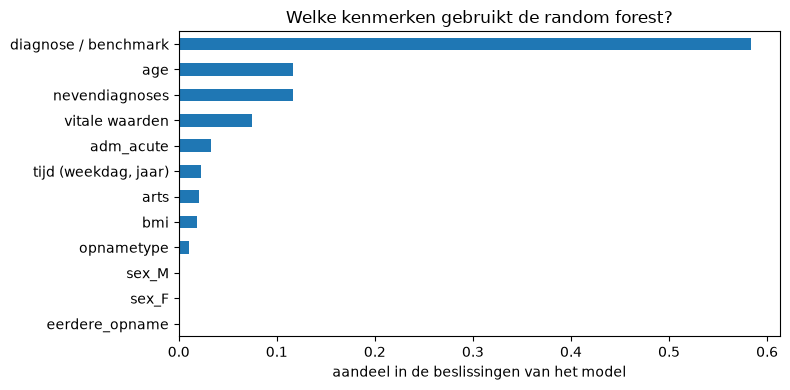

In [28]:
# ===== NB02 Cel 18 | Stap 3.5 | Plaatje van de feature importance =====
plt.figure(figsize=(8, 4))
imp_groep.sort_values().plot(kind="barh")
plt.xlabel("aandeel in de beslissingen van het model")
plt.title("Welke kenmerken gebruikt de random forest?")
plt.tight_layout()
plt.show()

In [29]:
# ===== NB02 Cel 19 | Stap 3.5 | Gewichten van het lineaire model, in dagen =====
# Het lineaire model geeft per kenmerk één gewicht: hoeveel dagen erbij per eenheid.
# Bij leeftijd is dat per jaar; bij ja/nee-kolommen is het het verschil tussen ja en nee.
lin = model_lineair.named_steps["model"]
namen_lin = voorbewerking_lineair.get_feature_names_out()
gewichten = pd.Series(lin.coef_, index=namen_lin).sort_values()

print("Meest negatief (korter):")
print(gewichten.head(6).round(2))
print("\nMeest positief (langer):")
print(gewichten.tail(8).round(2))

Meest negatief (korter):
cat__diagnosis_category_Gastrointestinal   -1.63
cat__diagnosis_category_Renal              -1.47
cat__diagnosis_category_Metabolic          -1.42
cat__diagnosis_category_Other              -1.27
cat__adm_type_P                            -0.59
num__temperature                           -0.07
dtype: float64

Meest positief (langer):
cat__adm_type_E                           0.57
cat__diagnosis_category_Neurological      0.99
num__typical_los_benchmark                1.04
cat__diagnosis_category_Cardiovascular    1.29
cat__diagnosis_category_Infectious        1.33
num__n_secondary                          1.41
num__adm_acute                            1.64
cat__diagnosis_category_Respiratory       2.16
dtype: float64
